## 12. Descida do Gradiente em Lote com Parada Antecipada para Regressão Softmax

Exercício: _Implemente a descida do gradiente em lote com parada antecipada para regressão Softmax sem usar Scikit-Learn para o treinamento, apenas NumPy. Use a implementação em uma tarefa de classificação, como o conjunto de dados Iris._

## Configuração e carregamento dos dados

Começamos carregando as bibliotecas necessárias e o conjunto Iris. O treinamento da regressão Softmax será implementado manualmente com NumPy; o Scikit-Learn será usado apenas para carregar o dataset.

In [1]:
import sys
from packaging import version

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import sklearn
from sklearn.datasets import load_iris

assert sys.version_info >= (3, 7)
assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

np.random.seed(42)

iris = load_iris(as_frame=True)

In [2]:
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = iris["target"].values

Precisamos adicionar o termo de viés para cada instância ($x_0 = 1$). A opção mais simples seria usar a função `add_dummy_feature()` do Scikit-Learn, mas o objetivo deste exercício é entender melhor os algoritmos implementando-os manualmente. Portanto, usamos uma implementação simples com NumPy:

In [3]:
X_with_bias = np.c_[np.ones(len(X)), X]

A forma mais simples de dividir o dataset em treino, validação e teste seria usar `train_test_split()` do Scikit-Learn, mas novamente faremos isso manualmente:

In [4]:
test_ratio = 0.2
validation_ratio = 0.2
total_size = len(X_with_bias)

test_size = int(total_size * test_ratio)
validation_size = int(total_size * validation_ratio)
train_size = total_size - test_size - validation_size

np.random.seed(42)
rnd_indices = np.random.permutation(total_size)

X_train = X_with_bias[rnd_indices[:train_size]]
y_train = y[rnd_indices[:train_size]]
X_valid = X_with_bias[rnd_indices[train_size:-test_size]]
y_valid = y[rnd_indices[train_size:-test_size]]
X_test = X_with_bias[rnd_indices[-test_size:]]
y_test = y[rnd_indices[-test_size:]]

Os alvos estão como índices de classe (0, 1 ou 2), mas precisamos de probabilidades-alvo por classe para treinar a regressão Softmax. Cada instância terá probabilidade `0.0` para todas as classes, exceto para a classe correta, que terá probabilidade `1.0`. Em outras palavras, o vetor de probabilidades de classe de cada instância será um vetor one-hot.

Vamos criar uma pequena função para converter o vetor de índices de classe em uma matriz com um vetor one-hot para cada instância. Para entender o código, lembre que `np.diag(np.ones(n))` cria uma matriz `n x n` cheia de zeros, exceto pela diagonal principal, que contém uns. Além disso, se `a` é um array NumPy, então `a[[1, 3, 2]]` retorna um array com três linhas: `a[1]`, `a[3]` e `a[2]`. Isso é [indexação avançada do NumPy](https://numpy.org/doc/stable/user/basics.indexing.html#advanced-indexing).

In [5]:
def to_one_hot(y):
    return np.diag(np.ones(y.max() + 1))[y]

Vamos testar a função nas 10 primeiras instâncias:

In [6]:
y_train[:10]

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1])

In [7]:
to_one_hot(y_train[:10])

array([[0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.]])

Funcionou. Agora vamos criar as matrizes de probabilidades-alvo para os conjuntos de treino, validação e teste:

In [8]:
Y_train_one_hot = to_one_hot(y_train)
Y_valid_one_hot = to_one_hot(y_valid)
Y_test_one_hot = to_one_hot(y_test)

Agora vamos escalonar as entradas. Calculamos a média e o desvio padrão de cada atributo no conjunto de treinamento, exceto o atributo de viés. Em seguida, centralizamos e escalonamos os atributos nos conjuntos de treino, validação e teste:

In [9]:
mean = X_train[:, 1:].mean(axis=0)
std = X_train[:, 1:].std(axis=0)
X_train[:, 1:] = (X_train[:, 1:] - mean) / std
X_valid[:, 1:] = (X_valid[:, 1:] - mean) / std
X_test[:, 1:] = (X_test[:, 1:] - mean) / std

Agora vamos implementar a função Softmax. Ela é definida pela seguinte equação:

$\sigma\left(\mathbf{s}(\mathbf{x})ight)_k = \dfrac{\exp\left(s_k(\mathbf{x})ight)}{\sum\limits_{j=1}^{K}{\exp\left(s_j(\mathbf{x})ight)}}$

In [10]:
def softmax(logits):
    exps = np.exp(logits)
    exp_sums = exps.sum(axis=1, keepdims=True)
    return exps / exp_sums

Estamos quase prontos para treinar. Vamos definir o número de entradas e saídas:

In [11]:
n_inputs = X_train.shape[1]  # == 3 (2 atributos mais o termo de viés)
n_outputs = len(np.unique(y_train))  # == 3 (existem 3 classes de Iris)

Agora vem a parte mais difícil: o treinamento. Teoricamente, é simples: basta traduzir as equações matemáticas para código Python. Na prática, pode ser trabalhoso, especialmente porque é fácil trocar a ordem dos termos ou dos índices. Você pode até acabar com um código que parece funcionar, mas que não calcula exatamente o que deveria.

Quando houver dúvida, escreva a dimensão de cada termo da equação e confira se os termos correspondentes no código têm dimensões compatíveis. Também ajuda avaliar cada termo separadamente e imprimi-los. A boa notícia é que você não precisará fazer isso todos os dias, pois tudo isso já é bem implementado pelo Scikit-Learn, mas esse exercício ajuda a entender o que acontece por baixo dos panos.

As equações necessárias são a função de custo:

$J(\mathbf{\Theta}) = - \dfrac{1}{m}\sum\limits_{i=1}^{m}\sum\limits_{k=1}^{K}{y_k^{(i)}\log\left(\hat{p}_k^{(i)}ight)}$

E a equação dos gradientes:

$
abla_{\mathbf{	heta}^{(k)}} \, J(\mathbf{\Theta}) = \dfrac{1}{m} \sum\limits_{i=1}^{m}{ \left ( \hat{p}^{(i)}_k - y_k^{(i)} ight ) \mathbf{x}^{(i)}}$

Observe que $\log\left(\hat{p}_k^{(i)}ight)$ pode não ser computável se $\hat{p}_k^{(i)} = 0$. Por isso, adicionamos um valor muito pequeno $\epsilon$ ao argumento do logaritmo para evitar valores `nan`.

In [12]:
eta = 0.5
n_epochs = 5001
m = len(X_train)
epsilon = 1e-5

np.random.seed(42)
Theta = np.random.randn(n_inputs, n_outputs)

for epoch in range(n_epochs):
    logits = X_train @ Theta
    Y_proba = softmax(logits)
    if epoch % 1000 == 0:
        Y_proba_valid = softmax(X_valid @ Theta)
        xentropy_losses = -(Y_valid_one_hot * np.log(Y_proba_valid + epsilon))
        print(epoch, xentropy_losses.sum(axis=1).mean())
    error = Y_proba - Y_train_one_hot
    gradients = 1 / m * X_train.T @ error
    Theta = Theta - eta * gradients

0 3.7085808486476917
1000 0.14519367480830644
2000 0.1301309575504088
3000 0.12009639326384539
4000 0.11372961364786884
5000 0.11002459532472425


Pronto. O modelo Softmax foi treinado. Vamos observar os parâmetros do modelo:

In [13]:
Theta

array([[ 0.41931626,  6.11112089, -5.52429876],
       [-6.53054533, -0.74608616,  8.33137102],
       [-5.28115784,  0.25152675,  6.90680425]])

Vamos fazer previsões no conjunto de validação e medir a acurácia:

In [14]:
logits = X_valid @ Theta
Y_proba = softmax(logits)
y_predict = Y_proba.argmax(axis=1)

accuracy_score = (y_predict == y_valid).mean()
accuracy_score

np.float64(0.9333333333333333)

O modelo parece razoável. Para completar o exercício, vamos adicionar um pouco de regularização $\ell_2$. O código de treinamento abaixo é parecido com o anterior, mas agora a perda tem uma penalidade $\ell_2$ adicional, e os gradientes recebem o termo extra correspondente. Note que não regularizamos o primeiro elemento de `Theta`, pois ele corresponde ao termo de viés. Também vamos testar a taxa de aprendizado `eta`.

In [15]:
eta = 0.5
n_epochs = 5001
m = len(X_train)
epsilon = 1e-5
alpha = 0.01  # hiperparâmetro de regularização

np.random.seed(42)
Theta = np.random.randn(n_inputs, n_outputs)

for epoch in range(n_epochs):
    logits = X_train @ Theta
    Y_proba = softmax(logits)
    if epoch % 1000 == 0:
        Y_proba_valid = softmax(X_valid @ Theta)
        xentropy_losses = -(Y_valid_one_hot * np.log(Y_proba_valid + epsilon))
        l2_loss = 1 / 2 * (Theta[1:] ** 2).sum()
        total_loss = xentropy_losses.sum(axis=1).mean() + alpha * l2_loss
        print(epoch, total_loss.round(4))
    error = Y_proba - Y_train_one_hot
    gradients = 1 / m * X_train.T @ error
    gradients += np.r_[np.zeros([1, n_outputs]), alpha * Theta[1:]]
    Theta = Theta - eta * gradients

0 3.7372
1000 0.3259
2000 0.3259
3000 0.3259
4000 0.3259
5000 0.3259


Por causa da penalidade $\ell_2$ adicional, a perda parece maior do que antes. Mas talvez o modelo tenha um desempenho melhor. Vamos verificar:

In [16]:
logits = X_valid @ Theta
Y_proba = softmax(logits)
y_predict = Y_proba.argmax(axis=1)

accuracy_score = (y_predict == y_valid).mean()
accuracy_score

np.float64(0.9333333333333333)

Neste caso, a penalidade $\ell_2$ não alterou a acurácia de validação. Uma alternativa seria ajustar melhor o hiperparâmetro `alpha`.

Agora vamos adicionar parada antecipada. Para isso, basta medir a perda no conjunto de validação a cada iteração e parar quando o erro começar a crescer.

In [17]:
eta = 0.5
n_epochs = 50_001
m = len(X_train)
epsilon = 1e-5
C = 100  # hiperparâmetro de regularização
best_loss = np.inf

np.random.seed(42)
Theta = np.random.randn(n_inputs, n_outputs)

for epoch in range(n_epochs):
    logits = X_train @ Theta
    Y_proba = softmax(logits)
    Y_proba_valid = softmax(X_valid @ Theta)
    xentropy_losses = -(Y_valid_one_hot * np.log(Y_proba_valid + epsilon))
    l2_loss = 1 / 2 * (Theta[1:] ** 2).sum()
    total_loss = xentropy_losses.sum(axis=1).mean() + 1 / C * l2_loss
    if epoch % 1000 == 0:
        print(epoch, total_loss.round(4))
    if total_loss < best_loss:
        best_loss = total_loss
    else:
        print(epoch - 1, best_loss.round(4))
        print(epoch, total_loss.round(4), "parada antecipada!")
        break
    error = Y_proba - Y_train_one_hot
    gradients = 1 / m * X_train.T @ error
    gradients += np.r_[np.zeros([1, n_outputs]), 1 / C * Theta[1:]]
    Theta = Theta - eta * gradients

0 3.7372
281 0.3256
282 0.3256 parada antecipada!


In [18]:
logits = X_valid @ Theta
Y_proba = softmax(logits)
y_predict = Y_proba.argmax(axis=1)

accuracy_score = (y_predict == y_valid).mean()
accuracy_score

np.float64(0.9333333333333333)

A acurácia de validação ainda não mudou, mas pelo menos a parada antecipada reduziu o tempo de treinamento.

Agora vamos plotar as previsões do modelo em todo o dataset. Lembre-se de escalonar todos os atributos fornecidos ao modelo:

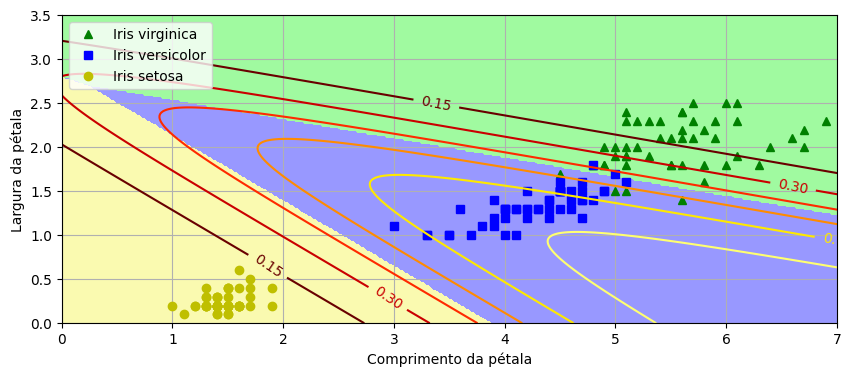

In [19]:
custom_cmap = mpl.colors.ListedColormap(['#fafab0', '#9898ff', '#a0faa0'])

x0, x1 = np.meshgrid(np.linspace(0, 8, 500).reshape(-1, 1),
                     np.linspace(0, 3.5, 200).reshape(-1, 1))
X_new = np.c_[x0.ravel(), x1.ravel()]
X_new = (X_new - mean) / std
X_new_with_bias = np.c_[np.ones(len(X_new)), X_new]

logits = X_new_with_bias @ Theta
Y_proba = softmax(logits)
y_predict = Y_proba.argmax(axis=1)

zz1 = Y_proba[:, 1].reshape(x0.shape)
zz = y_predict.reshape(x0.shape)

plt.figure(figsize=(10, 4))
plt.plot(X[y == 2, 0], X[y == 2, 1], "g^", label="Iris virginica")
plt.plot(X[y == 1, 0], X[y == 1, 1], "bs", label="Iris versicolor")
plt.plot(X[y == 0, 0], X[y == 0, 1], "yo", label="Iris setosa")

plt.contourf(x0, x1, zz, cmap=custom_cmap)
contour = plt.contour(x0, x1, zz1, cmap="hot")
plt.clabel(contour, inline=1)
plt.xlabel("Comprimento da pétala")
plt.ylabel("Largura da pétala")
plt.legend(loc="upper left")
plt.axis([0, 7, 0, 3.5])
plt.grid()
plt.show()

Agora vamos medir a acurácia final do modelo no conjunto de teste:

In [20]:
logits = X_test @ Theta
Y_proba = softmax(logits)
y_predict = Y_proba.argmax(axis=1)

accuracy_score = (y_predict == y_test).mean()
accuracy_score

np.float64(0.9666666666666667)

Obtivemos um desempenho ainda melhor no conjunto de teste. Essa variabilidade provavelmente acontece porque o dataset é muito pequeno: dependendo de como os conjuntos de treino, validação e teste são amostrados, os resultados podem mudar bastante. Experimente alterar a semente aleatória e executar o código novamente algumas vezes para observar essa variação.